# Model Training and Evaluation

### To-Do List:
1. **Load the Processed Dataset:**
   * Import the `eeg_rbp_features.csv` file generated in Notebook 01.
   * Separate the metadata (`subject_id`, `epoch_id`) from the actual features (X) and labels (y).

2. **Data Preprocessing & Encoding:**
   * Encode the categorical labels ('AD', 'FTD', 'CN') into numerical values using `LabelEncoder`.
   * Standardize/Scale the features (e.g., using `StandardScaler`). This is crucial for models like SVM or KNN that rely on distance metrics.

3. **Subject-Wise Data Splitting (CRITICAL):**
   * <u>Prevent Data Leakage</u> by ensuring that all epochs from a single subject stay entirely within the training set OR the testing set.
   * Implement `GroupKFold` or `Leave-One-Group-Out` cross-validation, using `subject_id` as the grouping variable.

4. **Model Selection & Training:**
   * Initialize baseline Machine Learning classifiers. Recommended starting points:
     * Support Vector Machine (SVM) - good for high-dimensional spaces.
     * Random Forest (RF) - handles non-linearities well and provides feature importance.
   * Train the models inside the cross-validation loop.

5. **Evaluation & Metrics:**
   * Calculate standard classification metrics: Accuracy, Precision, Recall, and F1-Score.

In [4]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "joblib"])

0

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.pipeline import Pipeline

PROCESSED_DIR = '../data/processed/'
MODELS_DIR = '../data/processed/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5  # GroupKFold folds

print('All imports successful.')

All imports successful.


In [6]:
# Load the feature matrix generated in Notebook 01
csv_path = os.path.join(PROCESSED_DIR, 'eeg_rbp_features.csv')
df = pd.read_csv(csv_path)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
print(f'\nUnique subjects: {df["subject_id"].nunique()}')
df.head()

Dataset shape: (34788, 98)

Class distribution:
label
AD     14514
CN     12012
FTD     8262
Name: count, dtype: int64

Unique subjects: 88


,subject_id,epoch_id,label,Fp1_Delta,Fp1_Theta,Fp1_Alpha,Fp1_Beta,Fp1_Gamma,Fp2_Delta,Fp2_Theta,...,Cz_Delta,Cz_Theta,Cz_Alpha,Cz_Beta,Cz_Gamma,Pz_Delta,Pz_Theta,Pz_Alpha,Pz_Beta,Pz_Gamma
0,sub-001,0,AD,0.912041,0.030483,0.014585,0.016458,0.026433,0.915544,0.036635,...,0.913046,0.051016,0.016633,0.011626,0.007678,0.913287,0.052040,0.015882,0.011856,0.006935
1,sub-001,1,AD,0.872221,0.059261,0.018784,0.022035,0.027700,0.882970,0.063469,...,0.887674,0.080962,0.013994,0.011464,0.005906,0.873384,0.092166,0.014435,0.014966,0.005050
2,sub-001,2,AD,0.850522,0.067376,0.016662,0.026871,0.038570,0.848940,0.078542,...,0.877214,0.086088,0.014794,0.015680,0.006224,0.875529,0.087580,0.016828,0.013160,0.006903
3,sub-001,3,AD,0.789663,0.106579,0.027835,0.026968,0.048955,0.780058,0.128467,...,0.813315,0.123527,0.031806,0.021084,0.010270,0.823936,0.110456,0.036709,0.019880,0.009019
4,sub-001,4,AD,0.823902,0.083011,0.024096,0.029004,0.039987,0.827565,0.097813,...,0.895633,0.059105,0.023580,0.015695,0.005986,0.897920,0.052712,0.027109,0.017268,0.004992


In [7]:
# Separate metadata from features and labels
METADATA_COLS = ['subject_id', 'epoch_id', 'label']
FEATURE_COLS  = [c for c in df.columns if c not in METADATA_COLS]

X      = df[FEATURE_COLS].values          # Feature matrix  (n_epochs, n_features)
groups = df['subject_id'].values          # Group vector    (n_epochs,)
y_raw  = df['label'].values               # String labels   (n_epochs,)

print(f'Feature matrix shape : {X.shape}')
print(f'Number of features   : {len(FEATURE_COLS)}')
print(f'Feature columns (first 10): {FEATURE_COLS[:10]}')

Feature matrix shape : (34788, 95)
Number of features   : 95
Feature columns (first 10): ['Fp1_Delta', 'Fp1_Theta', 'Fp1_Alpha', 'Fp1_Beta', 'Fp1_Gamma', 'Fp2_Delta', 'Fp2_Theta', 'Fp2_Alpha', 'Fp2_Beta', 'Fp2_Gamma']


In [8]:
# Encode categorical labels ('AD', 'FTD', 'CN') → integers
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print('Label encoding mapping:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} → {idx}')

# Note: StandardScaler is applied inside each cross-validation fold
# (via sklearn Pipeline) to avoid data leakage from the test fold.
print('\nStandardScaler will be applied inside the CV pipeline to prevent leakage.')

Label encoding mapping:
  AD → 0
  CN → 1
  FTD → 2

StandardScaler will be applied inside the CV pipeline to prevent leakage.


In [9]:
# Configure subject-wise GroupKFold cross-validation
gkf = GroupKFold(n_splits=N_SPLITS)

print(f'GroupKFold with {N_SPLITS} folds')
print(f'Total subjects: {len(np.unique(groups))}')
print(f'~{len(np.unique(groups)) // N_SPLITS} subjects held out per fold')

# Quick sanity check — verify no subject appears in both train and test
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    train_subs = set(groups[train_idx])
    test_subs  = set(groups[test_idx])
    assert len(train_subs & test_subs) == 0, f'Data leakage in fold {fold}!'
    print(f'  Fold {fold+1}: train={len(train_idx)} epochs ({len(train_subs)} subjects) | '
          f'test={len(test_idx)} epochs ({len(test_subs)} subjects)')

print('\n✓ No data leakage detected across all folds.')

GroupKFold with 5 folds
Total subjects: 88
~17 subjects held out per fold
  Fold 1: train=27956 epochs (71 subjects) | test=6832 epochs (17 subjects)
  Fold 2: train=27957 epochs (71 subjects) | test=6831 epochs (17 subjects)
  Fold 3: train=27814 epochs (70 subjects) | test=6974 epochs (18 subjects)
  Fold 4: train=27696 epochs (70 subjects) | test=7092 epochs (18 subjects)
  Fold 5: train=27729 epochs (70 subjects) | test=7059 epochs (18 subjects)

✓ No data leakage detected across all folds.


In [10]:
def make_pipeline(classifier):
    """Wraps a classifier in a StandardScaler → Classifier pipeline."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    classifier)
    ])

MODELS = {
    'KNN':                 make_pipeline(KNeighborsClassifier(n_neighbors=5)),
    'Decision Tree':       make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    'SVM':                 make_pipeline(SVC(kernel='rbf', C=1.0, probability=True,
                                            random_state=RANDOM_STATE)),
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1000,
                                                             random_state=RANDOM_STATE)),
    'LDA':                 make_pipeline(LinearDiscriminantAnalysis()),
}

SCORING = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print(f'Models to train: {list(MODELS.keys())}')
print(f'Scoring metrics: {SCORING}')

Models to train: ['KNN', 'Decision Tree', 'SVM', 'Logistic Regression', 'LDA']
Scoring metrics: ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']


In [11]:
# Train all models with GroupKFold cross-validation
cv_results = {}

for model_name, pipeline in MODELS.items():
    print(f'Training {model_name}...', end=' ')
    
    scores = cross_validate(
        pipeline, X, y,
        groups=groups,
        cv=gkf,
        scoring=SCORING,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[model_name] = scores
    
    mean_acc = scores['test_accuracy'].mean()
    print(f'Done. Mean accuracy: {mean_acc:.4f}')

print('\n✓ All models trained.')

Training KNN... Done. Mean accuracy: 0.4397
Training Decision Tree... Done. Mean accuracy: 0.4366
Training SVM... Done. Mean accuracy: 0.4974
Training Logistic Regression... Done. Mean accuracy: 0.5025
Training LDA... Done. Mean accuracy: 0.5225

✓ All models trained.


In [13]:
# Build a summary DataFrame with mean ± std for each metric
summary_rows = []

for model_name, scores in cv_results.items():
    row = {'Model': model_name}
    for metric in SCORING:
        key = f'test_{metric}'
        mean = scores[key].mean()
        std  = scores[key].std()
        # Nomes fixos para evitar inconsistência
        col_map = {
            'accuracy':          'Accuracy',
            'precision_macro':   'Precision Macro',
            'recall_macro':      'Recall Macro',
            'f1_macro':          'F1 Macro',
        }
        clean = col_map[metric]
        row[clean]            = mean
        row[f'{clean} Std']   = std
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')

display_cols = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1 Macro']
print('=== Cross-Validation Results (Mean over 5 folds) ===')
display(summary_df[display_cols].round(4).sort_values('Accuracy', ascending=False))

=== Cross-Validation Results (Mean over 5 folds) ===


,Accuracy,Precision Macro,Recall Macro,F1 Macro
Model,,,,
LDA,0.5225,0.4869,0.4869,0.4305
Logistic Regression,0.5025,0.4573,0.4861,0.4291
SVM,0.4974,0.4490,0.4783,0.4130
KNN,0.4397,0.4027,0.4317,0.3871
Decision Tree,0.4366,0.4128,0.4357,0.3938


In [14]:
# Identify best model by F1-Macro
best_model_name = summary_df['F1 Macro'].idxmax()
print(f'Best model by F1-Macro: {best_model_name}')
print(summary_df.loc[best_model_name, display_cols].round(4))

Best model by F1-Macro: LDA
Accuracy           0.5225
Precision Macro    0.4869
Recall Macro       0.4869
F1 Macro           0.4305
Name: LDA, dtype: float64


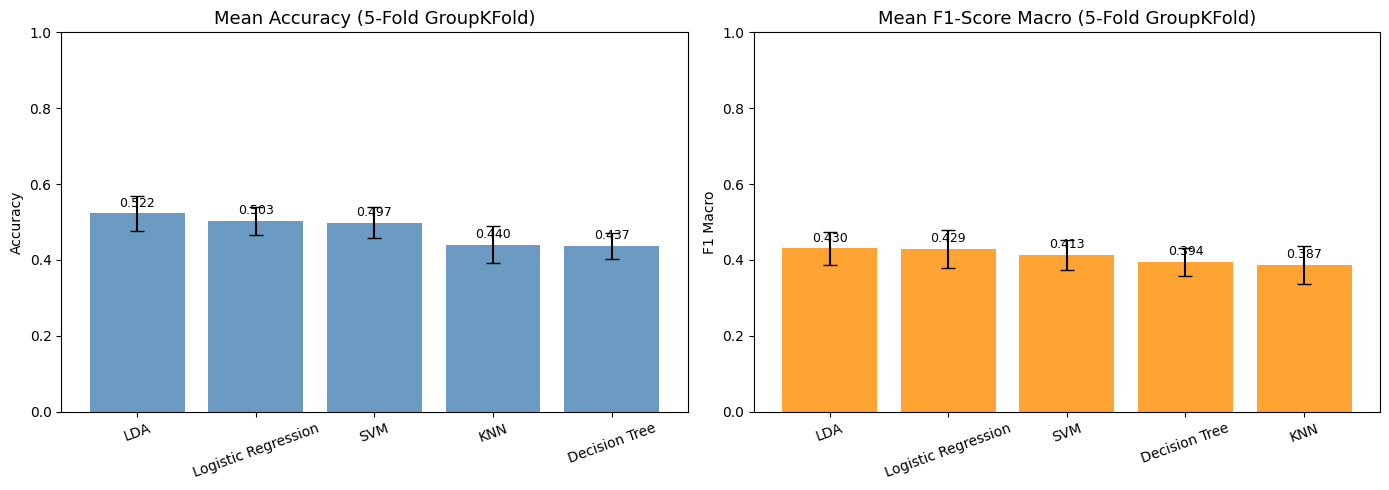

Plot saved to processed directory.


In [15]:
# Plot: Accuracy comparison bar chart with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_sorted = summary_df.sort_values('Accuracy', ascending=False)

# Accuracy
axes[0].bar(
    models_sorted.index,
    models_sorted['Accuracy'],
    yerr=models_sorted['Accuracy Std'],
    capsize=5, color='steelblue', alpha=0.8
)
axes[0].set_title('Mean Accuracy (5-Fold GroupKFold)', fontsize=13)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[0].patches, models_sorted['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# F1-Macro
models_f1 = summary_df.sort_values('F1 Macro', ascending=False)
axes[1].bar(
    models_f1.index,
    models_f1['F1 Macro'],
    yerr=models_f1['F1 Macro Std'],
    capsize=5, color='darkorange', alpha=0.8
)
axes[1].set_title('Mean F1-Score Macro (5-Fold GroupKFold)', fontsize=13)
axes[1].set_ylabel('F1 Macro')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(axes[1].patches, models_f1['F1 Macro']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'model_comparison.png'), dpi=150)
plt.show()
print('Plot saved to processed directory.')

In [16]:
# Retrain ALL models on the complete dataset and save them for Notebook 03
for model_name, pipeline in MODELS.items():
    pipeline.fit(X, y)
    safe_name = model_name.lower().replace(' ', '_')
    model_path = os.path.join(MODELS_DIR, f'{safe_name}.joblib')
    joblib.dump(pipeline, model_path)
    print(f'  Saved: {model_path}')

# Save the label encoder and feature columns for reproducibility
joblib.dump(le,           os.path.join(MODELS_DIR, 'label_encoder.joblib'))
joblib.dump(FEATURE_COLS, os.path.join(MODELS_DIR, 'feature_cols.joblib'))

# Save cv_results and summary for Notebook 03
summary_df.to_csv(os.path.join(PROCESSED_DIR, 'cv_summary.csv'))
joblib.dump(cv_results, os.path.join(PROCESSED_DIR, 'cv_results.joblib'))

print(f'\n✓ All models and metadata saved to {MODELS_DIR}')
print(f'✓ CV summary saved to {PROCESSED_DIR}cv_summary.csv')
print(f'\n→ Proceed to Notebook 03 for confusion matrices, ROC curves and full evaluation.')

  Saved: ../data/processed/models/knn.joblib
  Saved: ../data/processed/models/decision_tree.joblib
  Saved: ../data/processed/models/svm.joblib
  Saved: ../data/processed/models/logistic_regression.joblib
  Saved: ../data/processed/models/lda.joblib

✓ All models and metadata saved to ../data/processed/models/
✓ CV summary saved to ../data/processed/cv_summary.csv

→ Proceed to Notebook 03 for confusion matrices, ROC curves and full evaluation.
